# N1 · 世界模型 + MPC 规划 (零专家!)

> 配套 11.5-L1 · 从**纯随机探索**学一个世界模型 (state,action→Δ), 然后用 MPC 规划到目标。
> 关键: **不用任何专家 demo** —— 这是 model-based 的数据优势 (vs M11.4 BC 需专家)。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import world_model as wm
import toy_env as env   # M11.1 共享 (world_model 已加进 path)
import numpy as np, torch
print('环境 = M11.1 2D 到达; 世界模型与 M13.5 同源 (一面生成一面决策)')

环境 = M11.1 2D 到达; 世界模型与 M13.5 同源 (一面生成一面决策)


## 1. 从随机探索学世界模型 (无专家)

In [2]:
torch.manual_seed(0)
S, A, D = wm.make_random_transitions(n=4000, seed=0)   # 随机动作 + 看结果, 零专家!
print(f'随机探索转移: {len(S)} 个 (state, action, Δ) — 没有任何专家动作')
model = wm.build_world_model()
losses = wm.train_world_model(model, S, A, D, epochs=400)
print(f'世界模型训练: loss {losses[0]:.4f} → {losses[-1]:.4f} (学会了环境怎么动)')

随机探索转移: 4000 个 (state, action, Δ) — 没有任何专家动作


世界模型训练: loss 0.0065 → 0.0001 (学会了环境怎么动)


## 2. MPC 规划: 用世界模型想象 + 搜动作 → 到目标

MPC 规划成功率: 0.90 (只用随机数据学世界模型 + 规划)


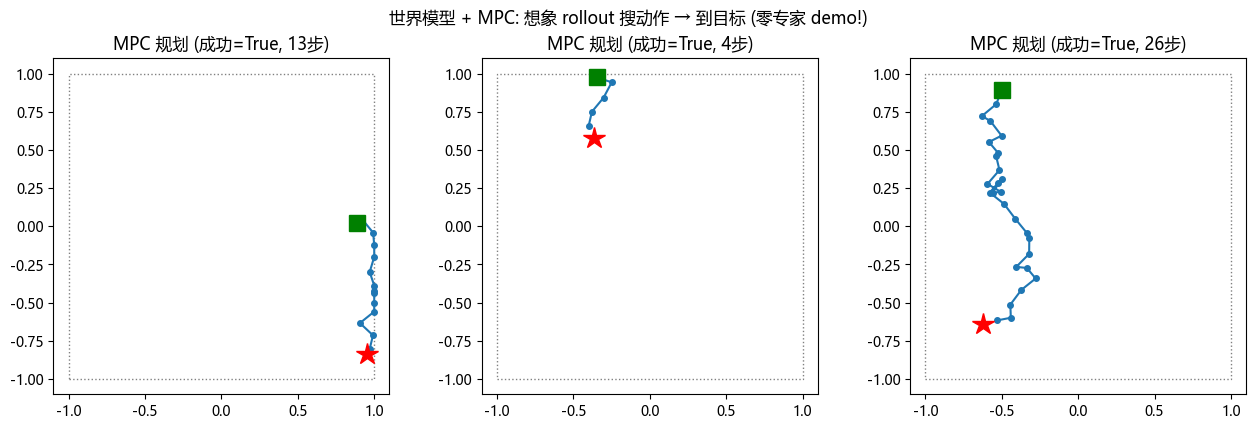

→ 不学策略, 靠世界模型想象 + 搜索就能控制 (规划)。数据来自随机探索, 没用专家。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
pol = wm.mpc_policy_fn(model, n_samples=200, horizon=6)
sr = env.eval_policy(pol, n_episodes=100)
print(f'MPC 规划成功率: {sr:.2f} (只用随机数据学世界模型 + 规划)')
fig, axes = plt.subplots(1,3,figsize=(13,4.2))
for ax, seed in zip(axes, [4,8,12]):
    ok,steps,traj = env.rollout(pol, seed=seed, record=True); traj=np.array(traj)
    ax.plot(traj[:,0],traj[:,1],'-o',ms=4); ax.plot(traj[0,0],traj[0,1],'gs',ms=12); ax.plot(traj[0,2],traj[0,3],'r*',ms=16)
    ax.add_patch(plt.Rectangle((-1,-1),2,2,fill=False,ls=':',ec='gray'))
    ax.set_title(f'MPC 规划 (成功={ok}, {steps}步)'); ax.set_aspect('equal')
plt.suptitle('世界模型 + MPC: 想象 rollout 搜动作 → 到目标 (零专家 demo!)'); plt.tight_layout(); plt.show()
print('→ 不学策略, 靠世界模型想象 + 搜索就能控制 (规划)。数据来自随机探索, 没用专家。')

## 3. 想象 vs 真实: 世界模型学得准吗 (误差累积)

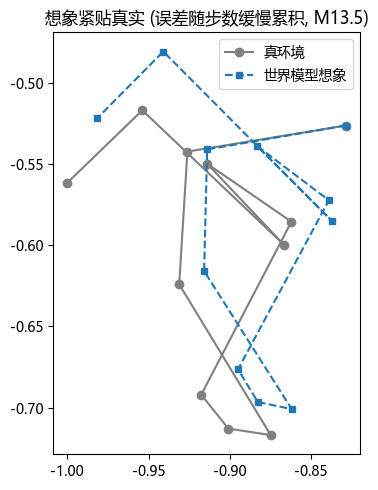

想象误差: 1步 0.012 → 10步 0.044 (累积, 故 MPC 用短视野+重规划)


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
# 给一串动作, 对比世界模型想象 vs 真环境
rng = np.random.default_rng(3)
s0 = env.reset(rng)
acts = rng.uniform(-1,1,size=(10,2)).astype(np.float32)
imag = [s0.copy()]; real = [s0.copy()]
si, sr_ = s0.copy(), s0.copy()
for a in acts:
    si = wm.imagine_next(model, si, a); imag.append(si.copy())
    sr_ = env.step(sr_, a); real.append(sr_.copy())
imag=np.array(imag); real=np.array(real)
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(real[:,0],real[:,1],'-o',label='真环境',color='gray',ms=6)
ax.plot(imag[:,0],imag[:,1],'--s',label='世界模型想象',color='C0',ms=5)
ax.legend(); ax.set_title('想象紧贴真实 (误差随步数缓慢累积, M13.5)'); ax.set_aspect('equal')
plt.tight_layout(); plt.show()
errs=np.linalg.norm(imag[:,:2]-real[:,:2],axis=1)
print(f'想象误差: 1步 {errs[1]:.3f} → 10步 {errs[10]:.3f} (累积, 故 MPC 用短视野+重规划)')

## 4. 反思
你用世界模型 + MPC 解了任务, **零专家 demo**。带走:
- **世界模型学转移** (从随机数据!), 学会后能想象 + 规划 (MPC) → 不学策略也能控制。
- **数据优势**: 随机探索数据就能学世界模型 (vs BC 需专家) — model-based 的杀手锏。
- **误差累积** (M13.5): 想象长了不准 → MPC 用短视野 + 每步重规划纠偏。
下一步 N2: 量化 model-based vs model-free 的样本效率。